# Disease Prediction — Multi-Model Comparative Study

This notebook trains and compares 6 machine learning models on the Disease Prediction dataset.

**Models compared:**
| Model |
|---|
| Logistic Regression |
| Decision Tree |
| Bernoulli Naive Bayes |
| Random Forest |
| XGBoost |
| K-Nearest Neighbors |

**Evaluation metrics:** Accuracy, Macro F1, Weighted F1, Precision, Recall, Training Time 

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import time
import warnings
from adjustText import adjust_text
warnings.filterwarnings('ignore')

# Sklearn — preprocessing & utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# SHAP for interpretability
import shap

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2', 8)

print('All imports successful.')

All imports successful.


## 2. Load Data

In [4]:
# Paths for dataset (# make sure the cwd is "Disease_Prediction_With_ML")

TRAIN_PATH = '../data/raw/Training.csv'
TEST_PATH  = '../data/raw/Testing.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Training set : {train_df.shape[0]} rows × {train_df.shape[1]} columns')
print(f'Test set     : {test_df.shape[0]} rows × {test_df.shape[1]} columns')
train_df.head()

Training set : 4920 rows × 133 columns
Test set     : 42 rows × 133 columns


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 3. Preprocessing

In [5]:
# --- 3.1 Separate features and target ---
FEATURE_COLS = [c for c in train_df.columns if c != 'prognosis']
TARGET_COL   = 'prognosis'

X_train = train_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

# --- 3.2 Encode target labels ---
le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET_COL])
y_test  = le.transform(test_df[TARGET_COL])

print(f'Feature matrix shape  : {X_train.shape}')
print(f'Number of classes     : {len(le.classes_)}')
print(f'Classes               : {list(le.classes_[:5])} ... (showing first 5)')

Feature matrix shape  : (4920, 132)
Number of classes     : 41
Classes               : ['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy'] ... (showing first 5)


## 4. Model Definitions

In [6]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=None, random_state=42
    ),
    'Bernoulli Naive Bayes': BernoulliNB(
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42,
        tree_method='hist'
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1
    ),
}

print(f'{len(MODELS)} models defined.')

6 models defined.


## 5. Train & Evaluate All Models

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in MODELS.items():
    print(f'Training: {name.replace(chr(10), " ")} ...')

    # --- Cross-validation ---
    cv_scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        return_train_score=False, n_jobs=-1
    )

    # --- Fit on full training set, evaluate on held-out test set ---
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    results.append({
        'Model': name.replace('\n', ' '),
        'CV Accuracy (mean)':    cv_scores['test_accuracy'].mean(),
        'CV Accuracy (std)':     cv_scores['test_accuracy'].std(),
        'CV Macro F1 (mean)':    cv_scores['test_f1_macro'].mean(),
        'CV Macro F1 (std)':     cv_scores['test_f1_macro'].std(),
        'CV Weighted F1 (mean)': cv_scores['test_f1_weighted'].mean(),
        'Test Accuracy':         accuracy_score(y_test, y_pred),
        'Test Macro F1':         f1_score(y_test, y_pred, average='macro'),
        'Test Weighted F1':      f1_score(y_test, y_pred, average='weighted'),
        'Test Precision (macro)':precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Test Recall (macro)':   recall_score(y_test, y_pred, average='macro', zero_division=0),
        'Train Time (s)':        round(train_time, 3),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('\nDone!')

Training: Logistic Regression ...
Training: Decision Tree ...
Training: Bernoulli Naive Bayes ...
Training: Random Forest ...
Training: XGBoost ...
Training: KNN ...

Done!


## 6. Creating Directory 

In [ ]:
from pathlib import Path

# Specify the path for the new directory
directory_path = Path("../results/comparison_results")

# Create the directory (and any missing parent directories)
try:
    directory_path.mkdir(parents=True, exist_ok=True)
    print(f"Directory '{directory_path}' created or already exists.")
except OSError as e:
    # Handle other potential OS errors (e.g., permission denied, invalid path)
    print(f"Error creating directory: {e}")

## 7. Results Summary Table

In [17]:
display_cols = [
    'CV Accuracy (mean)', 'CV Accuracy (std)',
    'CV Macro F1 (mean)', 'CV Macro F1 (std)',
    'Test Accuracy', 'Test Macro F1',
    'Test Precision (macro)', 'Test Recall (macro)',
    'Train Time (s)'
]

summary = results_df[display_cols].sort_values('Test Macro F1', ascending=False)
summary_pct = summary.copy()

for col in display_cols[:-1]:  # format all except Train Time as %
    summary_pct[col] = summary[col].map(lambda x: f'{x*100:.2f}%' if col != 'Train Time (s)' else x)

print('=== Model Comparison — Sorted by Test Macro F1 ===')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(summary_pct.to_string())

# Save to CSV
summary.to_csv('../results/comparison_results/model_comparison.csv')
print('\nSaved to ../results/comparison_results/model_comparison.csv')

=== Model Comparison — Sorted by Test Macro F1 ===
                      CV Accuracy (mean) CV Accuracy (std) CV Macro F1 (mean) CV Macro F1 (std) Test Accuracy Test Macro F1 Test Precision (macro) Test Recall (macro)  Train Time (s)
Model                                                                                                                                                                                 
Logistic Regression              100.00%             0.00%            100.00%             0.00%       100.00%       100.00%                100.00%             100.00%           0.250
Bernoulli Naive Bayes            100.00%             0.00%            100.00%             0.00%       100.00%       100.00%                100.00%             100.00%           0.034
KNN                              100.00%             0.00%            100.00%             0.00%       100.00%       100.00%                100.00%             100.00%           0.005
Decision Tree                    1

## 8. Comparison Visualizations

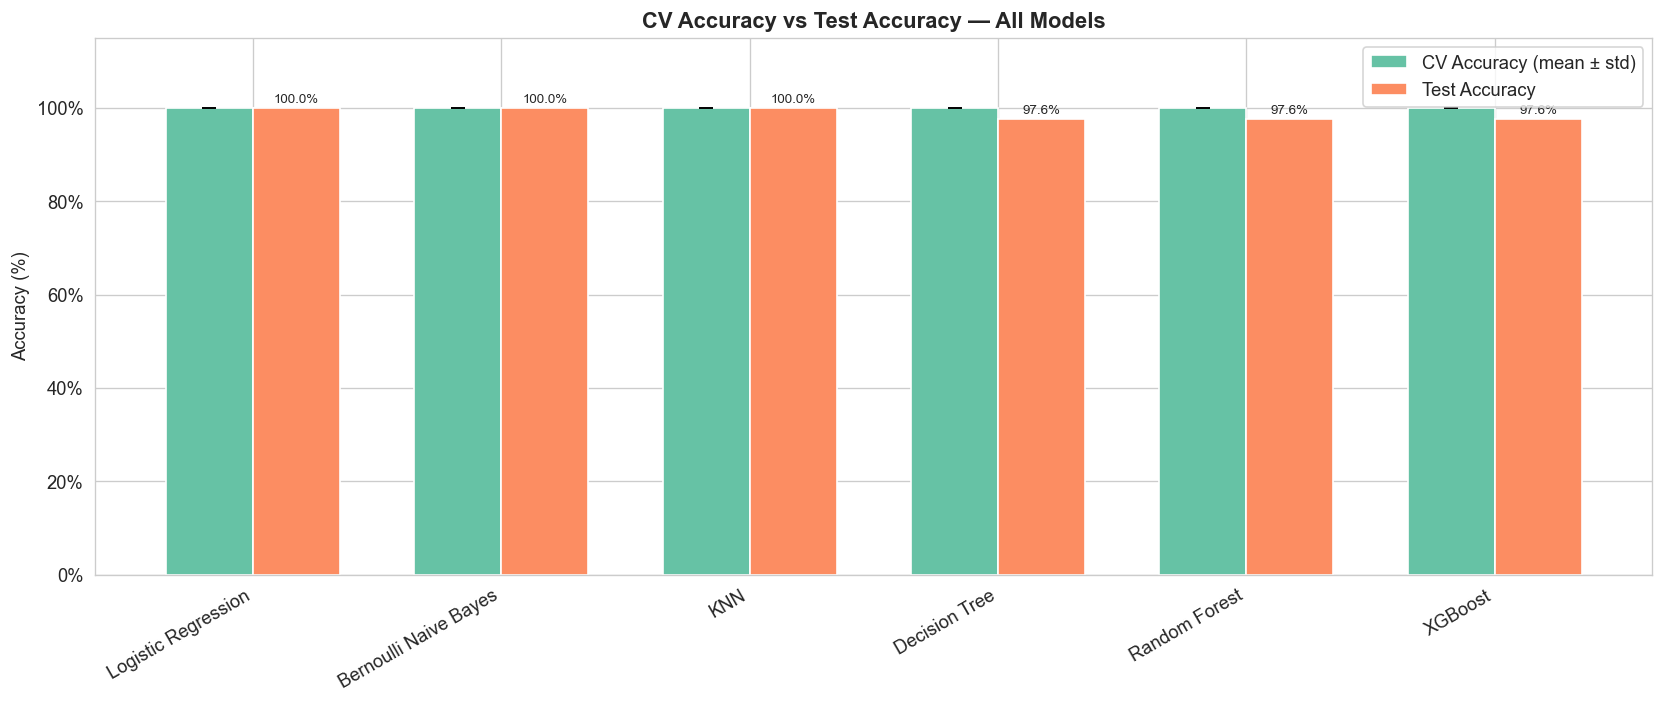

In [9]:
# --- 8.1 Grouped bar chart: CV Accuracy vs Test Accuracy ---
model_labels = summary.index

x = np.arange(len(summary))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, summary['CV Accuracy (mean)'] * 100,
               width, yerr=summary['CV Accuracy (std)'] * 100,
               label='CV Accuracy (mean ± std)', color=PALETTE[0], capsize=4)
bars2 = ax.bar(x + width/2, summary['Test Accuracy'] * 100,
               width, label='Test Accuracy', color=PALETTE[1])

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('CV Accuracy vs Test Accuracy — All Models', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f%%'))

# Annotate bars with values
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../results/comparison_results/accuracy_comparison.png', bbox_inches='tight')
plt.show()

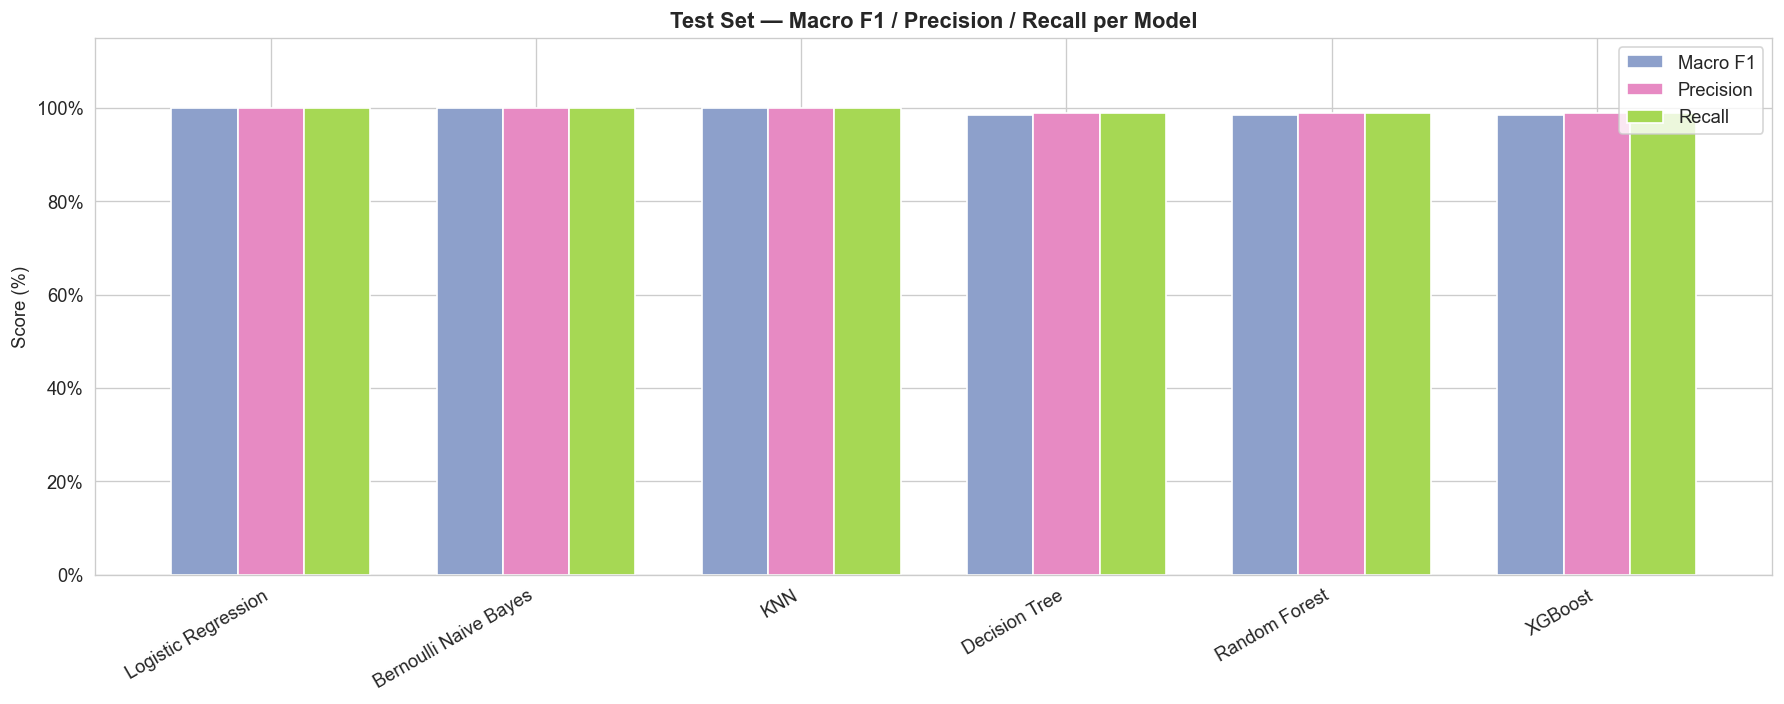

In [10]:
# --- 8.2 Multi-metric bar chart: F1, Precision, Recall on test set ---
metrics = ['Test Macro F1', 'Test Precision (macro)', 'Test Recall (macro)']
metric_labels = ['Macro F1', 'Precision', 'Recall']
x = np.arange(len(summary))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax.bar(x + (i - 1) * width, summary[metric] * 100,
           width, label=label, color=PALETTE[i+2])

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=30, ha='right')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Test Set — Macro F1 / Precision / Recall per Model', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('../results/comparison_results/f1_precision_recall_comparison.png', bbox_inches='tight')
plt.show()

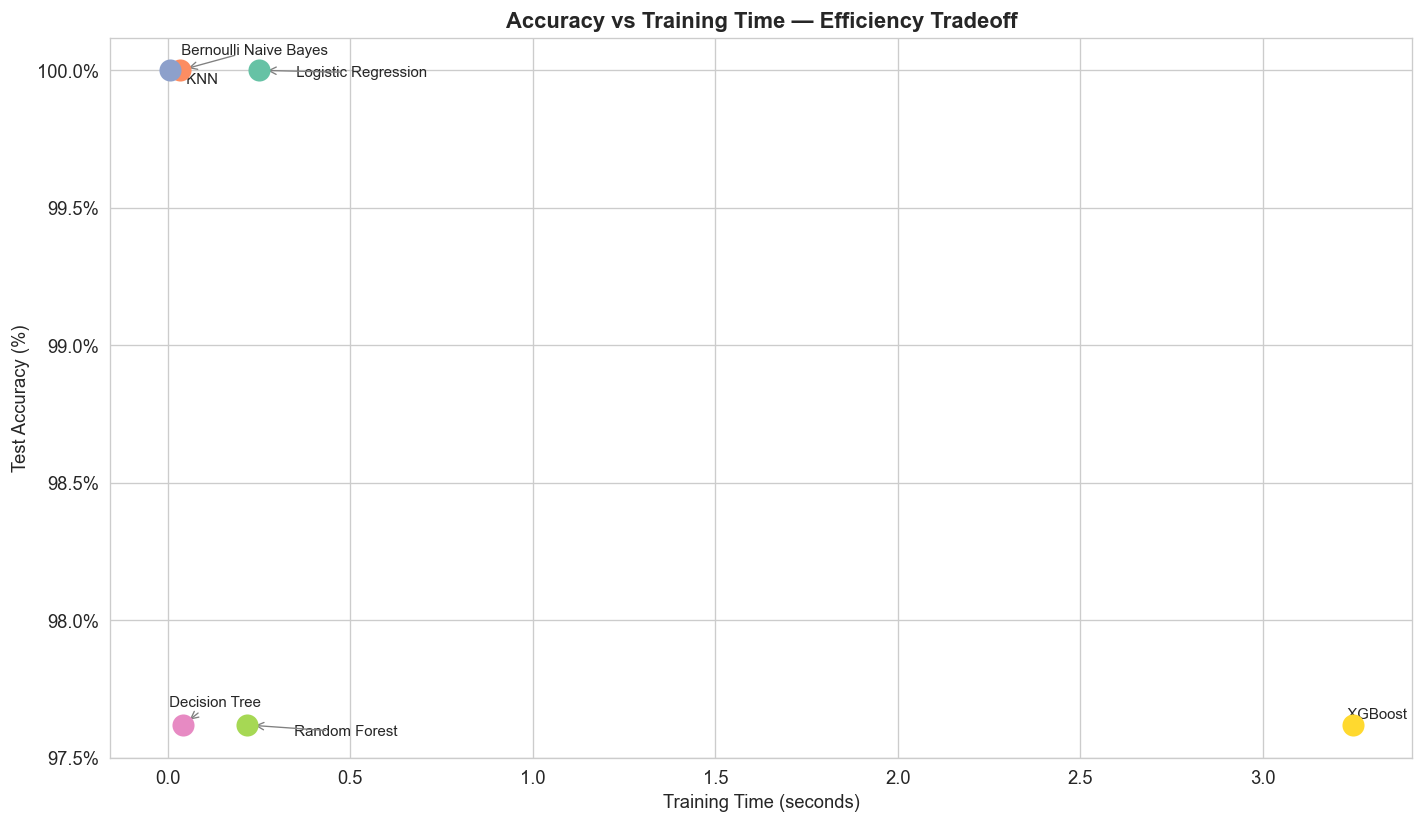

In [13]:
# --- 8.3 Accuracy vs Training Time scatter plot ---
fig, ax = plt.subplots(figsize=(12, 7))

texts = []
for i, (model_name, row) in enumerate(summary.iterrows()):
    ax.scatter(
        row['Train Time (s)'],
        row['Test Accuracy'] * 100,
        s=150, color=PALETTE[i], zorder=5
    )
    texts.append(ax.text(
        row['Train Time (s)'],
        row['Test Accuracy'] * 100,
        f'  {model_labels[i]}',
        fontsize=9
    ))

adjust_text(
    texts,
    ax            = ax,
    expand_points = (1.5, 1.5),
    expand_text   = (1.2, 1.2),
    force_text    = (0.5, 0.8),
    force_points  = (0.3, 0.5),
    arrowprops    = dict(
        arrowstyle = '->',
        color      = 'gray',
        lw         = 0.8,
        shrinkA    = 10,   # pulls arrow back from the text end
        shrinkB    = 5,    # pulls arrow back from the point end
    )
)

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy vs Training Time — Efficiency Tradeoff', fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
fig.savefig('../results/comparison_results/accuracy_vs_time.png', bbox_inches='tight')
plt.show()

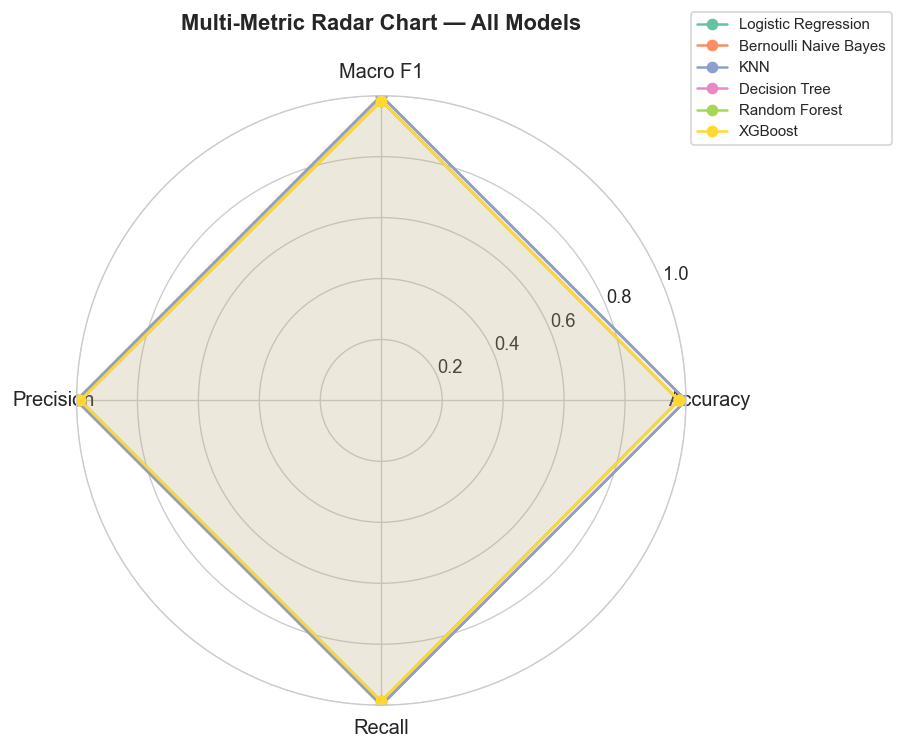

In [14]:
# --- 8.4 Radar chart comparing all models across 4 metrics ---
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['Test Accuracy', 'Test Macro F1', 'Test Precision (macro)', 'Test Recall (macro)']
radar_labels  = ['Accuracy', 'Macro F1', 'Precision', 'Recall']

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (model_name, row) in enumerate(summary.iterrows()):
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, color=PALETTE[i], label=model_labels[i])
    ax.fill(angles, values, alpha=0.05, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Radar Chart — All Models', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('../results/comparison_results/radar_chart.png', bbox_inches='tight')
plt.show()

## 9. Confusion Matrix — Best Model

In [ ]:
# Identify best model by Test Macro F1
best_model_name = summary['Test Macro F1'].idxmax()
best_model = MODELS[best_model_name]

# Fallback: find by iterating
for k, v in MODELS.items():
    if k.replace('\n', ' ') == best_model_name:
        best_model = v
        break

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/comparison_results/confusion_matrix_best.png', bbox_inches='tight')
plt.show()

print(f'\nBest model: {best_model_name}')
print(f'Test Macro F1: {summary.loc[best_model_name, "Test Macro F1"]*100:.2f}%')

## 10. Per-Class Performance — Hardest Diseases to Predict

In [ ]:
# Classification report as DataFrame
report = classification_report(
    y_test, y_pred_best,
    target_names=le.classes_,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
report_df = report_df.sort_values('f1-score', ascending=True)

# Plot bottom 15 (hardest to predict)
fig, ax = plt.subplots(figsize=(12, 7))
bottom15 = report_df.head(15)
x = np.arange(len(bottom15))
width = 0.25
ax.barh(x - width, bottom15['precision'], width, label='Precision', color=PALETTE[3])
ax.barh(x,         bottom15['recall'],    width, label='Recall',    color=PALETTE[4])
ax.barh(x + width, bottom15['f1-score'],  width, label='F1-Score',  color=PALETTE[5])
ax.set_yticks(x)
ax.set_yticklabels(bottom15.index)
ax.set_xlabel('Score')
ax.set_title(f'15 Hardest-to-Predict Diseases ({best_model_name})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/comparison_results/hardest_diseases.png', bbox_inches='tight')
plt.show()

## 11. Final Summary & Interpretation

In [15]:
print('=' * 70)
print('  FINAL MODEL COMPARISON SUMMARY')
print('=' * 70)

final_table = summary[['Test Accuracy', 'Test Macro F1', 'Test Precision (macro)',
                        'Test Recall (macro)', 'CV Macro F1 (mean)', 'Train Time (s)']].copy()

for col in final_table.columns[:-1]:
    final_table[col] = final_table[col].map(lambda x: f'{x*100:.2f}%')

print(final_table.to_string())

print('\n' + '=' * 70)
print('  KEY TAKEAWAYS')
print('=' * 70)
best_acc_model = summary['Test Accuracy'].idxmax()
best_f1_model  = summary['Test Macro F1'].idxmax()
fastest_model  = summary['Train Time (s)'].idxmin()

print(f'  Best by Test Accuracy  : {best_acc_model}')
print(f'  Best by Test Macro F1  : {best_f1_model}')
print(f'  Fastest to Train       : {fastest_model}')
print(f'  Baseline (LR) Macro F1 : {summary.filter(like="Logistic", axis=0)["Test Macro F1"].values[0]*100:.2f}%')
print('=' * 70)

  FINAL MODEL COMPARISON SUMMARY
                      Test Accuracy Test Macro F1 Test Precision (macro) Test Recall (macro) CV Macro F1 (mean)  Train Time (s)
Model                                                                                                                          
Logistic Regression         100.00%       100.00%                100.00%             100.00%            100.00%           0.250
Bernoulli Naive Bayes       100.00%       100.00%                100.00%             100.00%            100.00%           0.034
KNN                         100.00%       100.00%                100.00%             100.00%            100.00%           0.005
Decision Tree                97.62%        98.37%                 98.78%              98.78%            100.00%           0.042
Random Forest                97.62%        98.37%                 98.78%              98.78%            100.00%           0.216
XGBoost                      97.62%        98.37%                 98.78